<a href="https://colab.research.google.com/github/FX9919/Final-project-used-car-analysis/blob/main/Final_project_used_car__Analyse_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [172]:
import pandas as pd # impoet the libery i need
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [173]:
df = pd.read_csv('vehicles_features.csv')
# load the dataset after feature engineering

**histograms (distribution)  [ 1 ]**

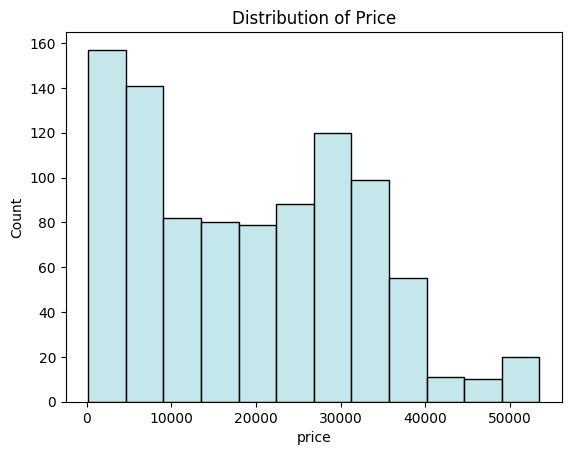

In [174]:
sns.histplot(df['price'],color='powderblue')
plt.title('Distribution of Price')
plt.show() # the most cars are low price and few are very expensive
# this means there are skewed
#-------------------------------------------------------------------
# اغلب السيارات رخيصه و بعضها غاليه و هذه يدل على وجود انحراف

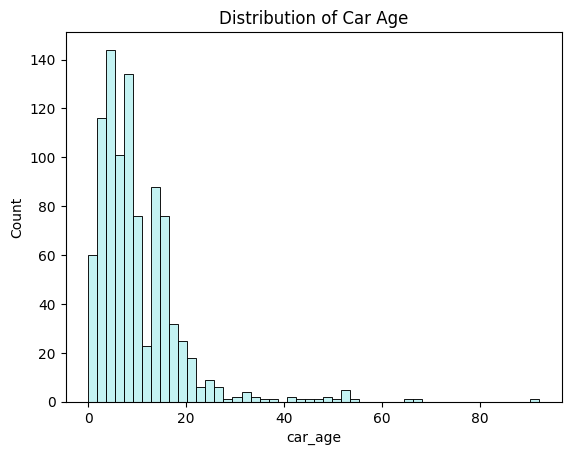

In [175]:
sns.histplot(df['car_age'],bins=50,color='paleturquoise')
plt.title('Distribution of Car Age')
plt.show()  # most cars are not very new and many are older cars
#---------------------------------------------------------------
# اغلب السيارات قديمه

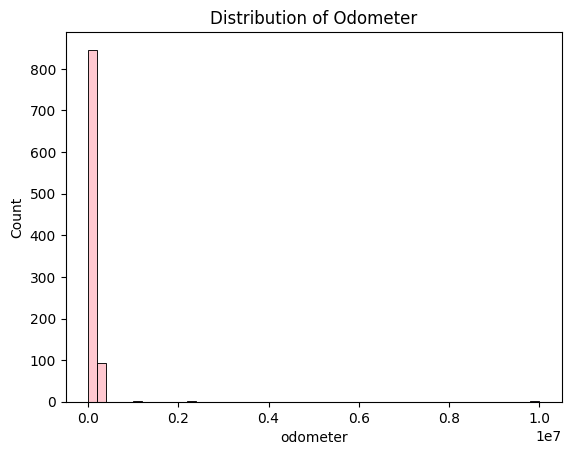

In [176]:
sns.histplot(df['odometer'], bins = 50,color='lightpink')
plt.title('Distribution of Odometer')
plt.show()
 # most cars have high mileage and fewer cars have low mileage
 #------------------------------------------------------------
 # اغلب السيارات ممشاها كثير  وقليل جداالي ممشاها قليل

**boxplot ( show outliers) [ 2 ]**

/tmp/ipykernel_523/2925088635.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x =df['age_group'],y=df['price'],palette='Pastel1')


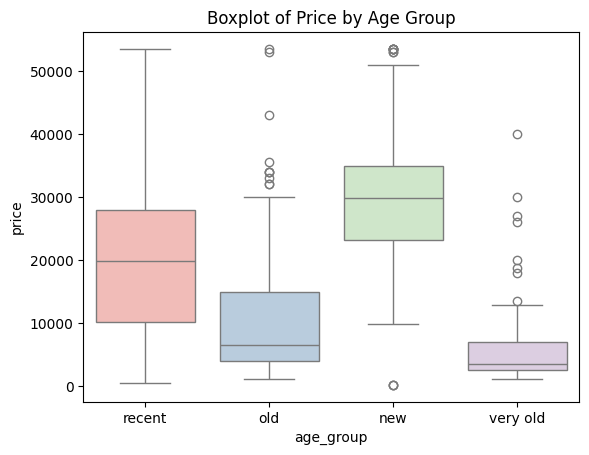

In [177]:
sns.boxplot(x =df['age_group'],y=df['price'],palette='Pastel1')
plt.title('Boxplot of Price by Age Group')
plt.show() # I compare price between different age groups ,  and new cars more expensive and older cars are cheaper
# car age affects the price
#-----------------------------------------------------------------------------------------------------------------
# هنا اقارن توزيع الاسعار بين فئات اعمار السياره ,
# ولو نلاحظ بانه السيارات الجديده اغلى و القديمه ارخص , بي معنى انه العمر اكيد ياثر على سعر بيعة السباره

**scatter plot ( to show relationship) [ 3 ] **

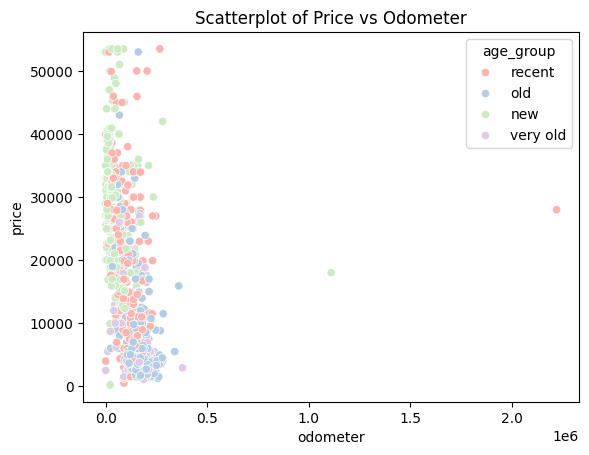

In [178]:
sns.scatterplot(x = df['odometer'], y = df['price'],hue =df['age_group'],palette='Pastel1')
plt.title('Scatterplot of Price vs Odometer')
plt.show() # there is a negative relationship between price and odometer
#------------------------------------------------------------------------------------------
# نلاحظ اولا ان العلاقه بين السعر و الكيلومتر علاقه عكسيه , يقل السعر كل ما زاد استخدام السياره
# واكييد كل ما كان استخدم السياره قلليل بتكون كانها جديده

bar plot (show average) [ 4 ]

/tmp/ipykernel_523/2269834899.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='price', data=df,palette='Pastel1')


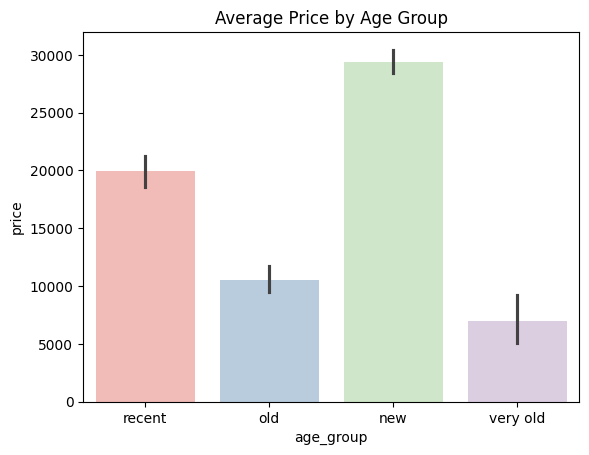

In [179]:
sns.barplot(x='age_group', y='price', data=df,palette='Pastel1')
plt.title('Average Price by Age Group')
plt.show()# I see that  new cars are more expensive
# and older cars are cheaper  so age affects price
#------------------------------------------------------------------------------------------------------
# الواضح بانه السيارات الجديده اغلى , و السيارات القديمه ارخص , ف طبععا عمرالسياره ياثر في سعرها

**heatmap ( correlation) [ 5 ]**

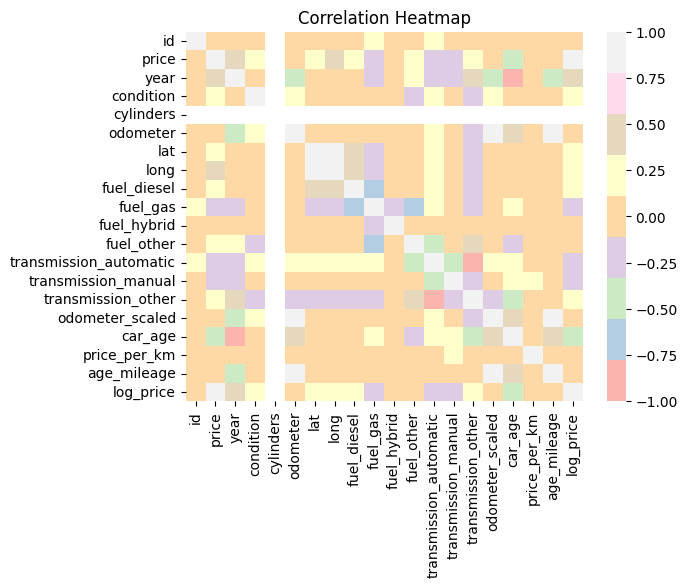

In [180]:
sns.heatmap(df.corr(numeric_only=True),cmap='Pastel1')
plt.title('Correlation Heatmap')
plt.show()# some features are strongly related
#so i remove one of the
#-------------------------------------------------------------------------------------------------
# هنا يوضح لي العلاقه بين المتغيرات مثل السعر و الكيلومتر وبعض الاعمده بضطر احذفها لنه تتشابه

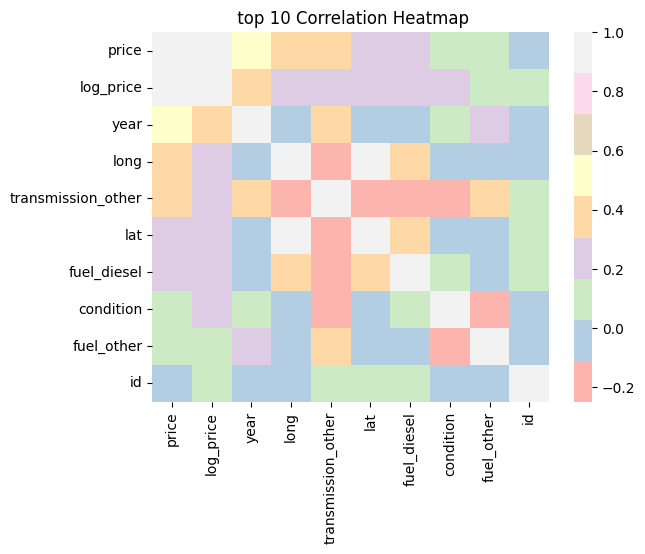

In [181]:
corr = df.corr(numeric_only=True)
# top_corr = corr.nlargest(10, 'price')['price']
# sns.heatmap(top_corr.to_frame(), cmap='Pastel1')
#---------------------------------------------------
top_corr =corr.nlargest(10, 'price')['price']
sns.heatmap(df[top_corr.index].corr(),cmap='Pastel1')
plt.title(' top 10 Correlation Heatmap') # i chose the top10 features
#--------------------------------------------------------------------------
plt.show()  #  اخترت اهم 10 اشياء له علاقه بالسعر الي توضلحي العلاقه بينهم

**groupby analysis [ 6 ]**

In [182]:
df.groupby('car_age')['price'].mean()
# I calculated average price for each age group
#this helps me understand price differences
# حسبنا متوسط سعر السياره مقارنه بي عمرها , عشان اعرف كيف يتغير السعر حسب عمر السياره
# ويوضح لي السياره الاحدث اغلى

,price
car_age,
0.0,12539.264361
1.0,32456.066667
2.0,31871.838668
3.0,28658.808045
4.0,28403.678160
5.0,26923.874712
6.0,23306.267857
7.0,22782.533333
8.0,17260.662791


**math (mean and std ) [ 7 ] **

In [183]:
mean_price=df['price'].sum()/len(df['price'])
print(mean_price) # to see the mean

19325.156928916134


In [184]:
std_price=df['price'].std()
print(std_price) # to see the standard deviation to show how spread the prices

12952.044041479356


**cosine similarity [ 8 ]**

In [185]:
cosine_similarity(df[['price','odometer']].dropna())
# checks if price and mileage move in the same direction or not
#-------------------------------------------------------------------------------------------------------------------------
# تقيس لي تشابه الاتجاه بين السعر و الكيلومترات وغالبا بتكون العلاقه عكسيه لانه السيارات الي استخدمها كثير تكون ارخص

array([[1.        , 0.9978809 , 0.98671186, ..., 0.99392197, 0.28701275,
        0.99278568],
       [0.9978809 , 1.        , 0.99519299, ..., 0.99897877, 0.34873397,
        0.99848356],
       [0.98671186, 0.99519299, 1.        , ..., 0.9986015 , 0.4388427 ,
        0.99907514],
       ...,
       [0.99392197, 0.99897877, 0.9986015 , ..., 1.        , 0.39072346,
        0.99995118],
       [0.28701275, 0.34873397, 0.4388427 , ..., 0.39072346, 1.        ,
        0.39979992],
       [0.99278568, 0.99848356, 0.99907514, ..., 0.99995118, 0.39979992,
        1.        ]])